# Poisson and Negative Binomial Noise in Single-Cell RNA-seq

## Real-World Scenario: Modeling Count Noise in scRNA-seq

Single-cell RNA sequencing (scRNA-seq) measures how many mRNA molecules of each gene are present in each cell. After droplet capture, reverse transcription, amplification, and sequencing, every gene-by-cell entry of the data matrix is a **nonnegative integer count** — sometimes zero, sometimes in the thousands.

These counts are noisy for two distinct reasons:

1. **Technical sampling noise.** Only a fraction of the mRNA molecules in a cell are actually captured and sequenced. Even if two cells had identical mRNA contents, their measured counts would differ because each molecule has a small, independent probability of being detected.
2. **Biological variation.** Real cells differ in their expression rate even within the same cell type: transcription is bursty, cell cycle phase varies, and ambient conditions fluctuate.

The **Poisson** distribution is the natural model for the first source alone. The **Negative Binomial** distribution extends it to capture both — it is the standard noise model in tools like `DESeq2`, `edgeR`, and `scVI`.

In this notebook we will:

- simulate the scRNA-seq sampling process and recover Poisson noise,
- show that real-looking gene counts are **overdispersed** (variance grows faster than the mean),
- derive the Negative Binomial as a **Gamma–Poisson mixture**,
- compare Poisson and Negative Binomial fits on the same data,
- and estimate per-gene dispersion across many genes.

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(11)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Step 1: The scRNA-seq Counting Process

Picture one cell. Inside it there are $M$ mRNA molecules of a given gene. During library preparation each molecule is captured with some small probability $q$, and the surviving molecules are then sequenced. The observed count is

$$Y = \sum_{j=1}^{M} Z_j, \qquad Z_j \sim \mathrm{Bernoulli}(q),$$

so $Y \sim \mathrm{Binomial}(M, q)$. When $M$ is large and $q$ is small, the Binomial is very well approximated by a Poisson:

$$Y \;\approx\; \mathrm{Poisson}(\mu), \qquad \mu = M q.$$

**Key takeaway.** If the true mRNA content $M$ were the same in every cell, the only source of count variation would be this capture step, and the counts would be Poisson with mean equal to the variance.

Expected mean count       Mq = 10.00
Empirical mean              = 10.08
Empirical variance          = 9.26
Fano factor (var / mean)    = 0.919


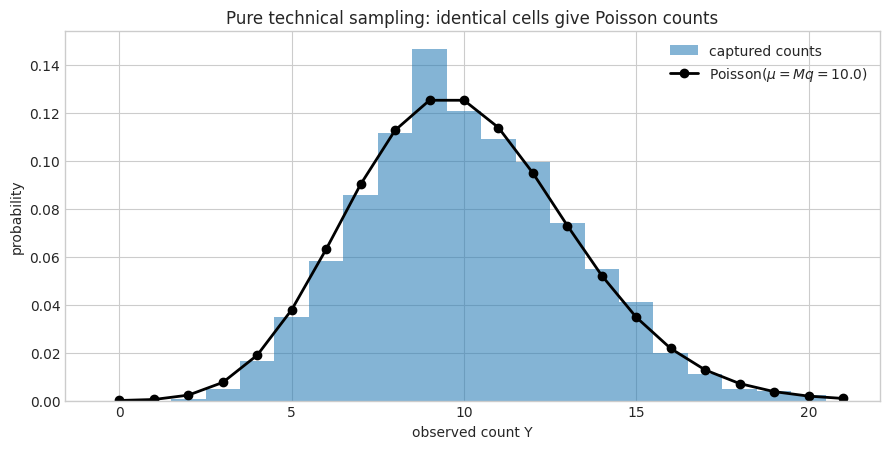

In [2]:
# A toy capture experiment: every cell starts with the same M mRNAs of one gene,
# each captured independently with probability q.
M_true = 400         # mRNA molecules per cell (same for all cells)
q_capture = 0.025    # capture probability per molecule (typical 1-10%)
n_cells = 2000

captured = np.random.binomial(M_true, q_capture, size=n_cells)

mu_expected = M_true * q_capture
print(f'Expected mean count       Mq = {mu_expected:.2f}')
print(f'Empirical mean              = {captured.mean():.2f}')
print(f'Empirical variance          = {captured.var(ddof=1):.2f}')
print(f'Fano factor (var / mean)    = {captured.var(ddof=1) / captured.mean():.3f}')

# Overlay Poisson PMF
def poisson_pmf(k, lam):
    k = np.asarray(k)
    log_fact = np.vectorize(math.lgamma)(k + 1)
    return np.exp(k * np.log(lam) - lam - log_fact)

k_grid = np.arange(0, captured.max() + 2)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(captured, bins=np.arange(-0.5, captured.max() + 1.5, 1), density=True,
        alpha=0.55, color='tab:blue', label='captured counts')
ax.plot(k_grid, poisson_pmf(k_grid, mu_expected), 'o-', color='black',
        linewidth=2, label=fr'Poisson($\mu = Mq = {mu_expected:.1f}$)')
ax.set_xlabel('observed count Y')
ax.set_ylabel('probability')
ax.set_title('Pure technical sampling: identical cells give Poisson counts')
ax.legend()
plt.tight_layout()
plt.show()

The Fano factor is essentially 1, exactly what Poisson noise predicts. The Binomial-to-Poisson approximation is excellent because the capture probability is small.

But this is a fiction: in reality, cells do **not** all contain the same number of mRNAs.

## Step 2: Real Cells Have Variable Expression

Even cells of the same type differ in their gene expression. Transcription happens in bursts, the cell cycle modulates global RNA content, and stochastic regulation creates cell-to-cell variation in mRNA levels.

Let the latent mRNA rate of cell $i$ be $\lambda_i$, drawn from some distribution with mean $\mu$ and variance $\sigma_\lambda^2$. The observed count is then

$$Y_i \mid \lambda_i \sim \mathrm{Poisson}(\lambda_i).$$

By the law of total variance,

$$\mathbb{E}[Y] = \mathbb{E}[\lambda] = \mu,$$

$$\mathrm{Var}(Y) = \mathbb{E}[\mathrm{Var}(Y \mid \lambda)] + \mathrm{Var}(\mathbb{E}[Y \mid \lambda]) = \mathbb{E}[\lambda] + \mathrm{Var}(\lambda) = \mu + \sigma_\lambda^2.$$

So the marginal variance is always **strictly larger** than the mean whenever the rate itself varies — this is the signature of **overdispersion**.

                            Poisson only     Overdispersed
mean                                5.03              4.97
variance                            5.30             12.73
Fano factor                         1.05              2.56
fraction of zeros                  0.80%             5.20%


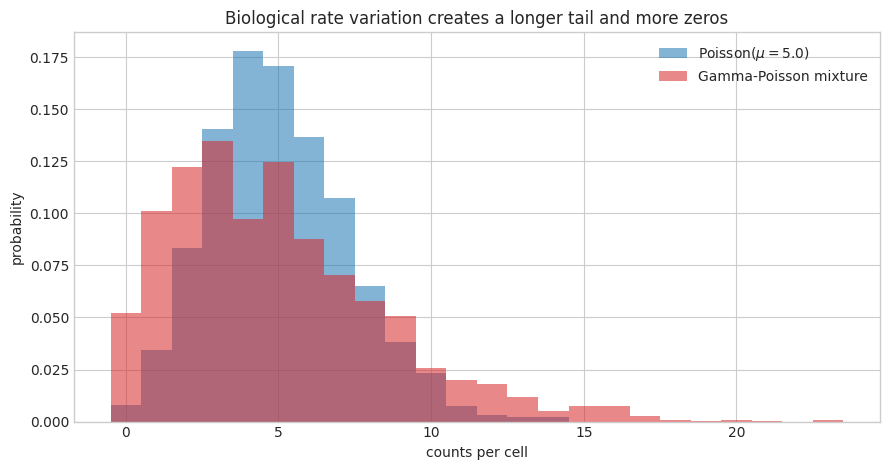

In [3]:
# Simulate cells whose true expression rate itself is random.
mu_marker = 5.0        # average count for a moderately expressed gene
r_dispersion = 3.0     # smaller r = more biological variability

# Gamma prior on the per-cell rate: shape=r, scale=mu/r  =>  mean=mu, var=mu^2/r
cell_rates = np.random.gamma(shape=r_dispersion, scale=mu_marker / r_dispersion, size=n_cells)
overdispersed_counts = np.random.poisson(cell_rates)

# A purely Poisson cohort with the same mean, for comparison
poisson_only = np.random.poisson(mu_marker, size=n_cells)

print(f'{"":24s}{"Poisson only":>16s}{"Overdispersed":>18s}')
print(f'{"mean":24s}{poisson_only.mean():16.2f}{overdispersed_counts.mean():18.2f}')
print(f'{"variance":24s}{poisson_only.var(ddof=1):16.2f}{overdispersed_counts.var(ddof=1):18.2f}')
print(f'{"Fano factor":24s}'
      f'{poisson_only.var(ddof=1) / poisson_only.mean():16.2f}'
      f'{overdispersed_counts.var(ddof=1) / overdispersed_counts.mean():18.2f}')
print(f'{"fraction of zeros":24s}'
      f'{(poisson_only == 0).mean():16.2%}'
      f'{(overdispersed_counts == 0).mean():18.2%}')

bins = np.arange(-0.5, max(poisson_only.max(), overdispersed_counts.max()) + 1.5, 1)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(poisson_only, bins=bins, density=True, alpha=0.55, color='tab:blue',
        label=fr'Poisson($\mu = {mu_marker}$)')
ax.hist(overdispersed_counts, bins=bins, density=True, alpha=0.55, color='tab:red',
        label='Gamma-Poisson mixture')
ax.set_xlabel('counts per cell')
ax.set_ylabel('probability')
ax.set_title('Biological rate variation creates a longer tail and more zeros')
ax.legend()
plt.tight_layout()
plt.show()

The overdispersed cohort has the **same mean** as the pure-Poisson cohort but:

- a much larger variance,
- noticeably more zero cells,
- and a longer right tail of cells with high counts.

These features — excess zeros and a heavy tail — are exactly what is observed in real scRNA-seq data.

## Step 3: The Negative Binomial as a Gamma–Poisson Mixture

If we put a **Gamma prior** on the per-cell rate,

$$\lambda_i \sim \mathrm{Gamma}\!\left(\text{shape}=r,\ \text{rate}=r/\mu\right), \qquad \mathbb{E}[\lambda]=\mu,\ \mathrm{Var}(\lambda) = \mu^2 / r,$$

and condition on it through a Poisson likelihood,

$$Y_i \mid \lambda_i \sim \mathrm{Poisson}(\lambda_i),$$

then the **marginal** distribution of $Y_i$ has a closed form: the **Negative Binomial** distribution.

Using the (mean, dispersion) parameterization,

$$p(Y = k \mid \mu, r) = \frac{\Gamma(k+r)}{\Gamma(r)\,k!}
\left(\frac{r}{r+\mu}\right)^{r}
\left(\frac{\mu}{r+\mu}\right)^{k},
\qquad k = 0, 1, 2, \dots$$

with mean and variance

$$\mathbb{E}[Y] = \mu, \qquad \mathrm{Var}(Y) = \mu + \frac{\mu^2}{r}.$$

The parameter $r$ controls the **excess** variance beyond Poisson: as $r \to \infty$ the Gamma prior collapses on $\mu$ and the NB recovers the Poisson; small $r$ means heavy overdispersion.

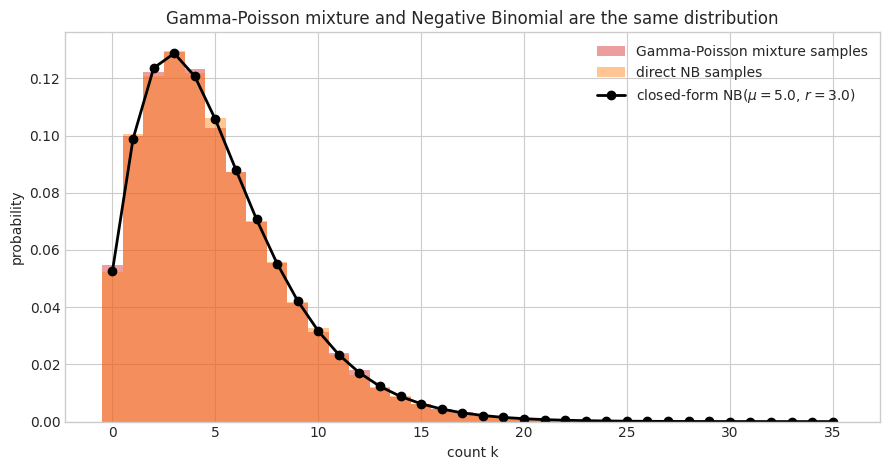

In [4]:
def nb_logpmf(k, mu, r):
    """Log PMF of NB in (mean, inverse-dispersion) parameterization."""
    k = np.asarray(k, dtype=float)
    lgam = np.vectorize(math.lgamma)
    log_coef = lgam(k + r) - lgam(r) - lgam(k + 1)
    return log_coef + r * np.log(r / (r + mu)) + k * np.log(mu / (r + mu))


def nb_pmf(k, mu, r):
    return np.exp(nb_logpmf(k, mu, r))


# Sanity check: sample from the NB two ways and compare to the closed-form PMF.
mu_demo, r_demo = 5.0, 3.0
n_demo = 50_000

rates_demo = np.random.gamma(shape=r_demo, scale=mu_demo / r_demo, size=n_demo)
y_from_mixture = np.random.poisson(rates_demo)

# Direct NB sampling via the (n, p) form: n=r, p = r / (r + mu)
y_direct = np.random.negative_binomial(r_demo, r_demo / (r_demo + mu_demo), size=n_demo)

k_grid = np.arange(0, max(y_from_mixture.max(), y_direct.max()) + 1)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(y_from_mixture, bins=np.arange(-0.5, k_grid[-1] + 1.5, 1), density=True,
        alpha=0.45, color='tab:red', label='Gamma-Poisson mixture samples')
ax.hist(y_direct, bins=np.arange(-0.5, k_grid[-1] + 1.5, 1), density=True,
        alpha=0.45, color='tab:orange', label='direct NB samples')
ax.plot(k_grid, nb_pmf(k_grid, mu_demo, r_demo), 'o-', color='black', linewidth=2,
        label=fr'closed-form NB($\mu={mu_demo}$, $r={r_demo}$)')
ax.set_xlabel('count k')
ax.set_ylabel('probability')
ax.set_title('Gamma-Poisson mixture and Negative Binomial are the same distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Shape Behaviour as Dispersion Varies

Holding the mean $\mu$ fixed and sweeping $r$ shows how the Negative Binomial interpolates between strongly overdispersed shapes (small $r$, heavy right tail, many zeros) and the Poisson (large $r$).

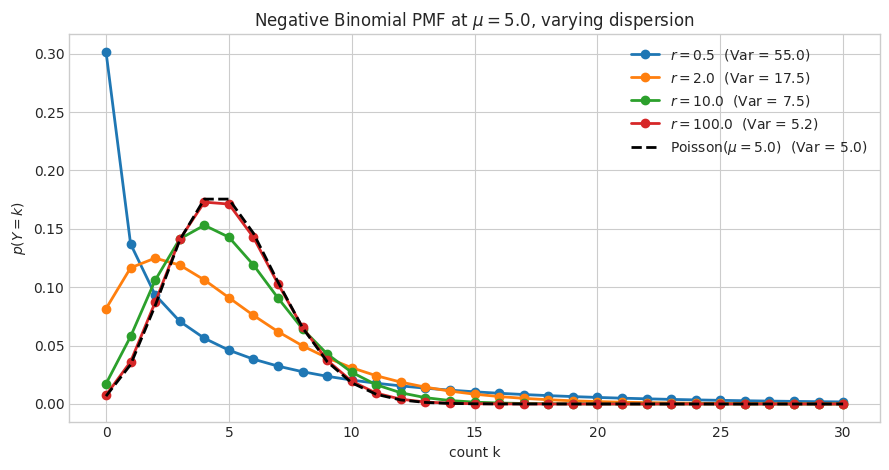

In [5]:
mu_fixed = 5.0
r_values = [0.5, 2.0, 10.0, 100.0]
k_grid = np.arange(0, 31)

fig, ax = plt.subplots(figsize=(9, 4.8))
for r in r_values:
    variance = mu_fixed + mu_fixed ** 2 / r
    ax.plot(k_grid, nb_pmf(k_grid, mu_fixed, r), marker='o', linewidth=2,
            label=fr'$r = {r}$  (Var = {variance:.1f})')
ax.plot(k_grid, poisson_pmf(k_grid, mu_fixed), color='black', linestyle='--', linewidth=2,
        label=fr'Poisson($\mu={mu_fixed}$)  (Var = {mu_fixed})')
ax.set_xlabel('count k')
ax.set_ylabel(r'$p(Y = k)$')
ax.set_title(fr'Negative Binomial PMF at $\mu = {mu_fixed}$, varying dispersion')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5: The Mean–Variance Relationship of scRNA-seq Counts

A standard diagnostic in scRNA-seq is to plot **per-gene variance against per-gene mean** across cells. Under each noise model the curve looks different:

- Poisson: $\mathrm{Var} = \mu$, a straight diagonal,
- Negative Binomial: $\mathrm{Var} = \mu + \mu^2 / r$, a parabola that bends upward.

Real scRNA-seq mean-variance plots almost always show the upward curvature predicted by the NB.

Let's simulate a small count matrix and reproduce that pattern.

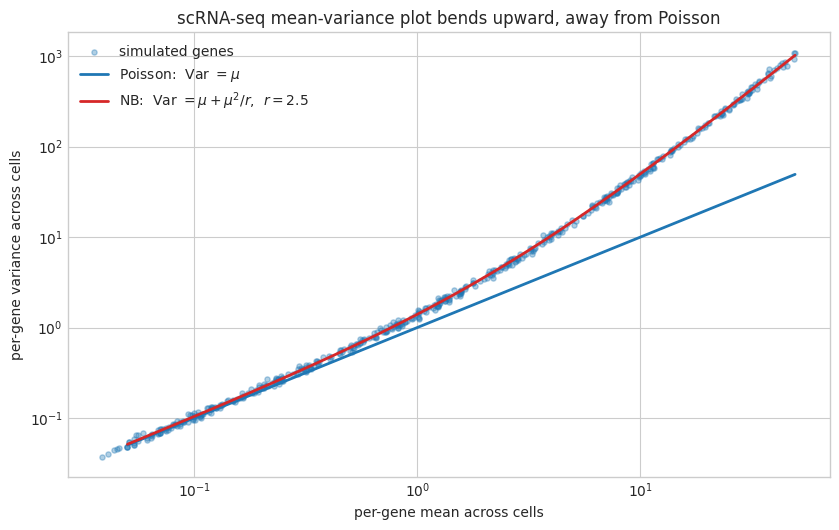

In [6]:
# Simulate counts for many genes across many cells under an NB model with shared r.
n_genes = 500
n_cells = 800
r_global = 2.5  # shared dispersion across genes (just for illustration)

# Gene means span several orders of magnitude (typical of real data).
gene_means = np.exp(np.random.uniform(np.log(0.05), np.log(50.0), size=n_genes))

# NB sampling per gene using the (n, p) form.
p_per_gene = r_global / (r_global + gene_means)
count_matrix = np.random.negative_binomial(r_global, p_per_gene[:, None],
                                            size=(n_genes, n_cells))

empirical_mean = count_matrix.mean(axis=1)
empirical_var = count_matrix.var(axis=1, ddof=1)

mu_curve = np.logspace(np.log10(gene_means.min()), np.log10(gene_means.max()), 200)

fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.scatter(empirical_mean, empirical_var, alpha=0.35, s=14, label='simulated genes')
ax.plot(mu_curve, mu_curve, color='tab:blue', linewidth=2,
        label=r'Poisson:  Var $= \mu$')
ax.plot(mu_curve, mu_curve + mu_curve ** 2 / r_global, color='tab:red', linewidth=2,
        label=fr'NB:  Var $= \mu + \mu^2/r$,  $r={r_global}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('per-gene mean across cells')
ax.set_ylabel('per-gene variance across cells')
ax.set_title('scRNA-seq mean-variance plot bends upward, away from Poisson')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

At low expression the genes hug the Poisson line — the cell-to-cell biological variability is small relative to the sampling noise. At high expression the points peel off and follow the NB curve, because the $\mu^2 / r$ term dominates.

## Step 6: Estimating Dispersion from One Gene

Given counts $y_1, \dots, y_N$ from a single gene we want to estimate both $\mu$ and $r$.

**Method of moments.** Match the first two empirical moments to the NB:

$$\hat\mu = \bar{y}, \qquad s^2 = \hat\mu + \frac{\hat\mu^2}{\hat r} \ \Longrightarrow\ \hat r = \frac{\hat\mu^2}{s^2 - \hat\mu}.$$

This estimator is defined only when $s^2 > \hat\mu$, i.e. when the data are actually overdispersed. If $s^2 \le \hat\mu$, $r \to \infty$ and a Poisson model already suffices.

**Maximum likelihood.** $\hat\mu$ is still the sample mean, but $\hat r$ must be found numerically by maximizing

$$\ell(r) = \sum_i \log p(y_i \mid \hat\mu, r).$$

We will do a 1-D grid search.

true mu, r            = 8.002, 2.50
sample mean           = 8.139
sample variance       = 37.669
method-of-moments r   = 2.243
maximum-likelihood r  = 2.377


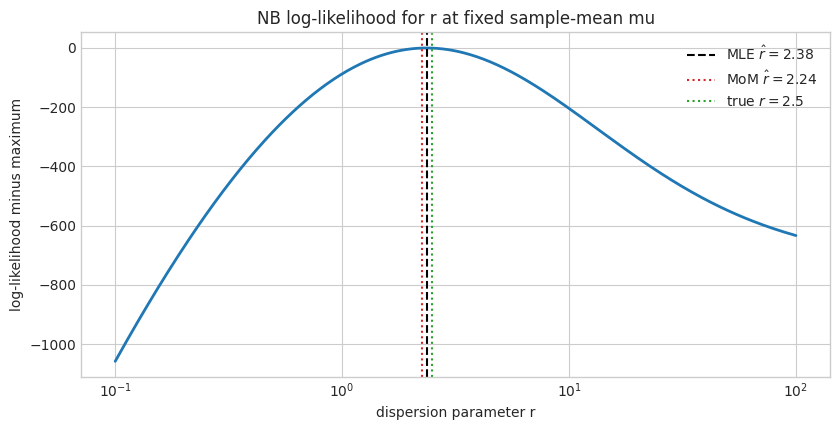

In [7]:
# Pick one moderately expressed gene from the simulated matrix.
gene_idx = int(np.argmin(np.abs(gene_means - 8.0)))
y = count_matrix[gene_idx]

mu_hat = y.mean()
s2 = y.var(ddof=1)
r_mom = mu_hat ** 2 / (s2 - mu_hat) if s2 > mu_hat else np.inf

# MLE for r via a 1-D grid search at fixed mu = sample mean.
def nb_loglik(y, mu, r):
    return nb_logpmf(y, mu, r).sum()

r_grid = np.logspace(-1, 2, 400)
log_lik = np.array([nb_loglik(y, mu_hat, r) for r in r_grid])
r_mle = r_grid[np.argmax(log_lik)]

print(f'true mu, r            = {gene_means[gene_idx]:.3f}, {r_global:.2f}')
print(f'sample mean           = {mu_hat:.3f}')
print(f'sample variance       = {s2:.3f}')
print(f'method-of-moments r   = {r_mom:.3f}')
print(f'maximum-likelihood r  = {r_mle:.3f}')

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(r_grid, log_lik - log_lik.max(), linewidth=2)
ax.axvline(r_mle, color='black', linestyle='--', label=fr'MLE $\hat r = {r_mle:.2f}$')
ax.axvline(r_mom, color='tab:red', linestyle=':', label=fr'MoM $\hat r = {r_mom:.2f}$')
ax.axvline(r_global, color='tab:green', linestyle=':', label=fr'true $r = {r_global}$')
ax.set_xscale('log')
ax.set_xlabel('dispersion parameter r')
ax.set_ylabel('log-likelihood minus maximum')
ax.set_title('NB log-likelihood for r at fixed sample-mean mu')
ax.legend()
plt.tight_layout()
plt.show()

## Step 7: Poisson vs Negative Binomial Fit on the Same Gene

Now we directly compare the two noise models on the gene above by overlaying their fitted PMFs on the count histogram and computing per-cell log-likelihoods.

Poisson per-cell log-likelihood:  -3.9696
NB      per-cell log-likelihood:  -3.0465
NB - Poisson log-likelihood gain: 738.5 over 800 cells


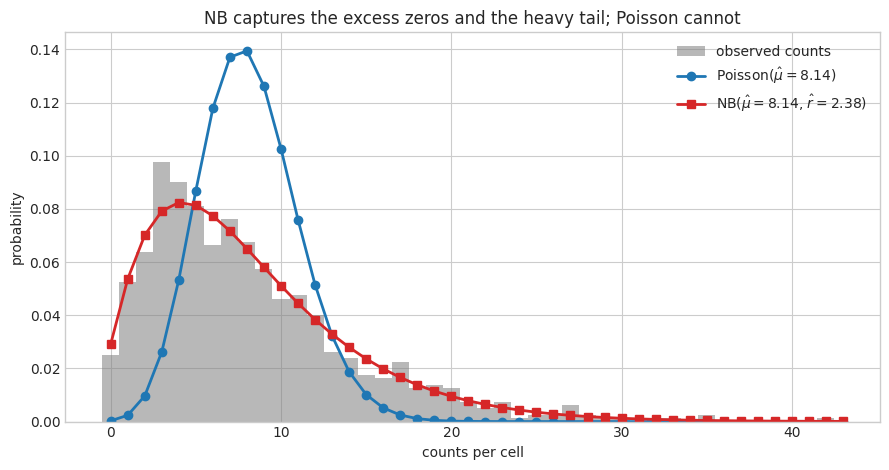

In [8]:
k_grid = np.arange(0, y.max() + 2)

poisson_loglik_total = (y * np.log(mu_hat) - mu_hat
                        - np.array([math.lgamma(int(yi) + 1) for yi in y])).sum()
nb_loglik_total = nb_loglik(y, mu_hat, r_mle)

print(f'Poisson per-cell log-likelihood:  {poisson_loglik_total / len(y):.4f}')
print(f'NB      per-cell log-likelihood:  {nb_loglik_total / len(y):.4f}')
print(f'NB - Poisson log-likelihood gain: {nb_loglik_total - poisson_loglik_total:.1f} '
      f'over {len(y)} cells')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(y, bins=np.arange(-0.5, y.max() + 1.5, 1), density=True,
        alpha=0.55, color='tab:gray', label='observed counts')
ax.plot(k_grid, poisson_pmf(k_grid, mu_hat), 'o-', color='tab:blue', linewidth=2,
        label=fr'Poisson($\hat\mu = {mu_hat:.2f}$)')
ax.plot(k_grid, nb_pmf(k_grid, mu_hat, r_mle), 's-', color='tab:red', linewidth=2,
        label=fr'NB($\hat\mu = {mu_hat:.2f}$, $\hat r = {r_mle:.2f}$)')
ax.set_xlabel('counts per cell')
ax.set_ylabel('probability')
ax.set_title('NB captures the excess zeros and the heavy tail; Poisson cannot')
ax.legend()
plt.tight_layout()
plt.show()

The Poisson curve is too narrow: it underpredicts the zeros and underpredicts the high counts. The Negative Binomial spreads out and matches both ends of the distribution. The per-cell log-likelihood difference, scaled by the number of cells, becomes large quickly — which is why all modern scRNA-seq analysis tools use NB-based likelihoods.

## Step 8: Genes Differ in Their Dispersion

In practice dispersion is not a single shared number — it varies gene by gene. Highly expressed housekeeping genes are often close to Poisson, while bursty regulatory genes can have very small $r$ (heavy overdispersion).

To illustrate, we simulate a fresh matrix where each gene has its **own** dispersion, then plot the estimated $r$ as a function of expression level.

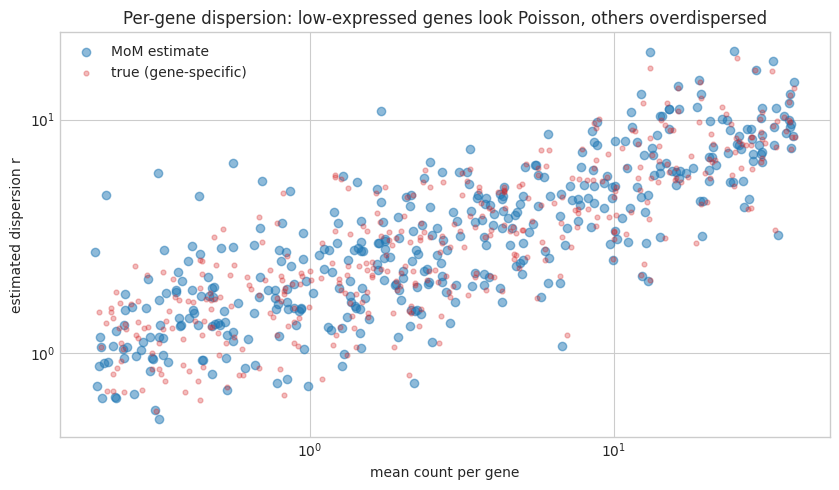

In [9]:
n_genes2 = 400
gene_means2 = np.exp(np.random.uniform(np.log(0.2), np.log(40.0), size=n_genes2))
# Per-gene dispersion: higher-expressed genes tend to have larger r (closer to Poisson).
r_per_gene = np.exp(np.random.normal(loc=np.log(2.0) + 0.4 * np.log(gene_means2),
                                      scale=0.4))

p_per_gene = r_per_gene / (r_per_gene + gene_means2)
count_matrix2 = np.random.negative_binomial(r_per_gene[:, None], p_per_gene[:, None],
                                             size=(n_genes2, n_cells))

# Method-of-moments dispersion estimate per gene.
mu_hat2 = count_matrix2.mean(axis=1)
s2_hat2 = count_matrix2.var(axis=1, ddof=1)
with np.errstate(divide='ignore', invalid='ignore'):
    r_hat2 = np.where(s2_hat2 > mu_hat2,
                       mu_hat2 ** 2 / (s2_hat2 - mu_hat2),
                       np.inf)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ok = np.isfinite(r_hat2) & (r_hat2 > 0)
ax.scatter(mu_hat2[ok], r_hat2[ok], alpha=0.5, label='MoM estimate')
ax.scatter(gene_means2, r_per_gene, alpha=0.3, color='tab:red', s=12,
           label='true (gene-specific)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('mean count per gene')
ax.set_ylabel('estimated dispersion r')
ax.set_title('Per-gene dispersion: low-expressed genes look Poisson, others overdispersed')
ax.legend()
plt.tight_layout()
plt.show()

Method of moments gives noisy single-gene estimates, especially for low-expression genes where many cells have zero counts. Production tools (`DESeq2`, `edgeR`, `scVI`) regularize these estimates by sharing information across genes — for example, by fitting a smooth mean–dispersion trend and shrinking individual gene estimates toward it.

## Step 9: Why It Matters for Downstream Analysis

Choosing the right noise model affects every step that follows in a scRNA-seq pipeline:

- **Differential expression.** Under Poisson, $\mathrm{SE}(\hat\mu) \approx \sqrt{\mu/N}$. Under NB, the standard error is
  $\sqrt{(\mu + \mu^2/r)/N}$, which can be much larger. Using Poisson on overdispersed data **inflates significance** and produces false-positive marker genes.
- **Highly variable gene selection.** Many feature-selection methods (e.g., `scanpy`'s `seurat_v3` flavour) explicitly use the NB mean–variance trend to decide which genes are *unexpectedly* variable.
- **Latent variable models.** `scVI` and related deep generative models for scRNA-seq use a Negative Binomial (or Zero-Inflated NB) likelihood; the encoder learns a low-dimensional cell representation and the decoder outputs $(\mu, r)$ per gene per cell.
- **Library size normalization.** With size factors $s_i$, the NB becomes $Y_i \sim \mathrm{NB}(s_i \mu, r)$, exactly mirroring the Poisson exposure adjustment but keeping the extra variance term.

## Summary

| Concept | Result |
|---|---|
| Pure technical sampling | $Y \sim \mathrm{Binomial}(M, q) \approx \mathrm{Poisson}(Mq)$ |
| Variable biological rate | $Y \mid \lambda \sim \mathrm{Poisson}(\lambda),\ \lambda$ random |
| Total variance (law of total variance) | $\mathrm{Var}(Y) = \mathbb{E}[\lambda] + \mathrm{Var}(\lambda)$ |
| Gamma-Poisson mixture is NB | $\lambda \sim \mathrm{Gamma}(r, r/\mu) \ \Rightarrow\ Y \sim \mathrm{NB}(\mu, r)$ |
| NB mean and variance | $\mathbb{E}[Y] = \mu,\ \mathrm{Var}(Y) = \mu + \mu^2 / r$ |
| Method-of-moments dispersion | $\hat r = \hat\mu^2 / (s^2 - \hat\mu)$ |
| Poisson limit | $r \to \infty$ |

Key takeaways:

1. Poisson noise is the **floor** of count uncertainty — it captures the unavoidable molecular sampling step in any sequencing experiment.
2. Real cells are biologically variable, so observed scRNA-seq counts almost always show variance **larger** than the mean.
3. The Negative Binomial extends the Poisson by adding a $\mu^2 / r$ term, derived cleanly from a Gamma prior on the per-cell rate.
4. On overdispersed data, fitting Poisson underestimates variance and inflates significance; fitting NB recovers both the zeros and the heavy tail.
5. Dispersion is **gene-specific** in real data, which is why state-of-the-art tools estimate $r$ per gene with information sharing across genes.